<div class="notebook-nav"><a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey/access_matrix.ipynb">&larr; Previous: 3. The Constraint Matrix</a> &middot; <a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey.ipynb">Journey home</a></div>

# 4. Pretraining: Learning the Data Distribution

**Pretraining.** Use broad data to learn a reusable base model of the data distribution, before later
stages specialize, align, compress, or deploy that model.

In pretraining, the target is the data law $P$. We never receive that law as a formula. We receive a
dataset: finite examples drawn from it. Pretraining must turn those examples into a model that can
produce new samples with the same distributional structure.

## 1. What goes in, and what must come out

Pretraining starts with four ingredients:

| Ingredient | Role |
|:---|:---|
| Data examples $y\sim P$ | show what the target distribution looks like |
| Easy source law $P_Z$ | supplies randomness we can sample freely |
| Parameterized model $G_\theta$ | turns source randomness into a candidate sample |
| Comparison $D$ | measures how the model law disagrees with the data law |

Drawing $z\sim P_Z$ and applying the model produces

$$
x=G_\theta(z),
\qquad
Q_\theta=(G_\theta)_\#P_Z.
\tag{4.1}
$$

The population goal is

$$
\theta^\star
=
\arg\min_\theta D(Q_\theta,P).
\tag{4.2}
$$

The output is therefore not one generated point. It is a set of parameters whose **whole output
law** approximates the data law, together with whatever interface the trained model exposes: perhaps
a density, a direct sampler, a score, or a velocity field.

In practice, the dataset and its minibatches provide finite approximations to this population goal.
The source draws and data examples are samples from two laws, not paired input-output answers; unless
a method deliberately constructs a coupling, pretraining matches their distributions rather than
regressing each $z_i$ to an arbitrary $y_i$.

## 2. Forward KL creates the first fork

Suppose we choose forward KL for the population objective:

$$
\mathrm{KL}(P\,\|\,Q_\theta)
=
\mathbb{E}_{y\sim P}
\left[
\log p(y)-\log q_\theta(y)
\right].
\tag{4.3}
$$

The target law $P$ does not change with $\theta$, so its unknown log-density disappears when we
differentiate:

$$
\nabla_\theta \mathrm{KL}(P\,\|\,Q_\theta)
=
-
\mathbb{E}_{y\sim P}
\left[
\nabla_\theta\log q_\theta(y)
\right].
\tag{4.4}
$$

This is maximum likelihood. It does **not** require the data density $p(y)$. It requires only data
samples $y\sim P$ and a differentiable model log-density $\log q_\theta(y)$ at those samples.

| Quantity or operation | Available? | Role in forward-KL training |
|:---|:---:|:---|
| Data samples $y\sim P$ | yes | approximate the expectation |
| Data log-density $\log p(y)$ | no | unnecessary because it is constant in $\theta$ |
| Model samples $x\sim Q_\theta$ | yes | not enough for maximum likelihood |
| Model log-density $\log q_\theta(y)$ | generally no | the one missing operation |

The Gaussian source is generous: we can sample and evaluate it. But after an unconstrained neural
map pushes it into $Q_\theta$, sampling and differentiation through generated points survive while
density evaluation usually does not. That single red cross creates two natural strategies.

**Strategy A -- keep forward KL; change the model.** Constrain or augment the model until it exposes
an exact likelihood or a tractable likelihood bound. Normalizing flows buy a density through
invertibility, VAEs buy a bound through an auxiliary encoder, and autoregressive models buy an exact
density through the chain rule.

**Strategy B -- keep the free-form generator; change the comparison.** If both $P$ and $Q_\theta$
can be sampled, replace forward KL by a discrepancy computable from those samples. A discriminator,
kernel average, projection, or transport problem can compare the two sample clouds without ever
evaluating $q_\theta$.

A changes the model to preserve the desired comparison. B changes the comparison to preserve the
desired model freedom. Both are direct responses to the unavailable model density.

## 3. Endpoint matching creates the second fork

A and B differ in what they make computable, but both train against the **finished model law**
$Q_\theta$. They ask the endpoint produced by the model to match the data endpoint $P$ directly.

Direct endpoint matching can work extremely well. But it can also make the entire global
reorganization one hard learning problem when the source and target have very different geometry.
Strategy A may need restrictive structure, an approximation, or sequential factorization to
represent that change. Strategy B may receive weak or unstable sample-comparison gradients when the
two laws barely overlap. The symptoms differ, but both suggest that the endpoint problem may not
provide enough intermediate structure.

**Strategy C -- introduce a path.** Instead of asking the model to solve only the source-to-data
endpoint problem, construct intermediate laws

$$
P_0=P_Z,
\qquad
\{P_t\}_{0<t<1},
\qquad
P_1=P.
\tag{4.5}
$$

The path is designed so nearby states overlap and local movement is easier to learn. Diffusion
creates these states by gradually adding noise to data and learns how to reverse that corruption.
Flow matching samples interpolated states and learns the velocity that should move them along the
path. In both cases, sampled data, sampled noise, and a known corruption or interpolation rule create
local regression targets without requiring the model density.

| Obstruction | What changes | Strategy |
|:---|:---|:---|
| Forward KL needs unavailable $\log q_\theta$ | make likelihood usable | **A. Manufacture a density** |
| Forward KL needs unavailable $\log q_\theta$ | replace KL by a sample comparison | **B. Compare samples directly** |
| Direct endpoint matching is too difficult | replace one global match by local pathwise matches | **C. Introduce a path** |

These are organizing moves rather than mutually exclusive labels. A modern system may combine a
latent model, a sample comparison, and a learned path. The useful question is which move creates the
training signal at each point in the system.

## 4. A lightweight two-dimensional example

The following pretraining chapters use the same example so the strategies can be compared directly.
Both source and target live in the sample space $\mathbb{R}^2$:

$$
P_Z=\mathcal N(0,I),
\qquad
P=\frac{1}{8}\sum_{k=1}^{8}\mathcal N(\mu_k,0.3^2I),
\tag{4.6}
$$

where the eight means $\mu_k$ are equally spaced on a circle of radius $4$. The source is one diffuse
Gaussian cloud; the target contains eight narrow modes separated by low-density regions. A finite
sample from that ring plays the role of the training dataset.

This example is lightweight enough to train every method on CPU and to plot the complete sample
space. Its Euclidean geometry is also meaningful: nearby points really are similar, so distances,
transport, interpolation, and the shape of low-density gaps can be read directly from a figure.

That clarity is an extreme simplification of real generative modeling. Images and learned latent
representations occupy high-dimensional spaces, and coordinate distance need not agree with semantic
similarity. The example preserves the distributional difficulties we want to inspect—multiple modes,
separated mass, and a large source-to-target geometric change—while removing most of the scale and
representation difficulties.

Chapter 5 begins with Strategy A: change the model until its density can be used.

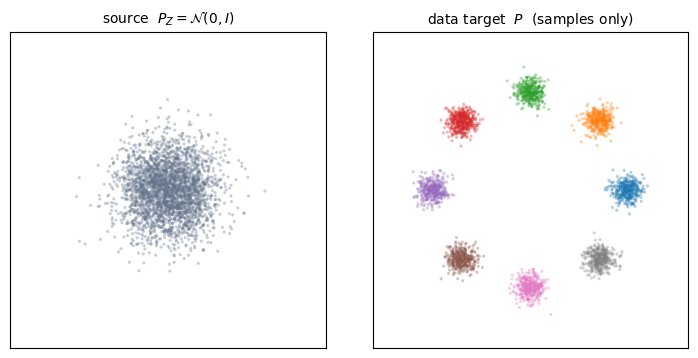

In [1]:
from __future__ import annotations
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)


N_MODES = 8
RING_RADIUS = 4.0
MODE_STD = 0.30
EVAL_N = 3000

angles = torch.arange(N_MODES) * (2 * math.pi / N_MODES)
MODE_CENTERS = torch.stack(
    [RING_RADIUS * torch.cos(angles), RING_RADIUS * torch.sin(angles)],
    dim=1,
)
MODE_COLORS = [plt.get_cmap("tab10")(k) for k in range(N_MODES)]


def sample_ring(n, weights=None):
    '''Draw samples from the eight-component Gaussian ring.'''
    if weights is None:
        component = torch.randint(0, N_MODES, (n,))
    else:
        component = torch.multinomial(weights, n, replacement=True)
    return MODE_CENTERS[component] + MODE_STD * torch.randn(n, 2)


def sample_source(n):
    '''Draw samples from the two-dimensional standard Gaussian source.'''
    return torch.randn(n, 2)


def assign_modes(x):
    '''Return the nearest ring-mode index for each sample.'''
    return torch.cdist(x, MODE_CENTERS).argmin(1)


def plot_samples(ax, x, title="", color="#1d4ed8", by_mode=False):
    '''Plot a two-dimensional sample cloud on the shared canvas.'''
    x = x.detach().cpu()
    colors = (
        [MODE_COLORS[k] for k in assign_modes(x).tolist()]
        if by_mode
        else color
    )
    ax.scatter(
        x[:, 0],
        x[:, 1],
        s=5,
        alpha=0.35,
        c=colors,
        edgecolors="none",
    )
    ax.set_xlim(-6.5, 6.5)
    ax.set_ylim(-6.5, 6.5)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])


DATA = sample_ring(EVAL_N)


fig, ax = plt.subplots(1, 2, figsize=(7.4, 3.6))
plot_samples(ax[0], sample_source(EVAL_N), r"source  $P_Z=\mathcal{N}(0,I)$", color="#64748b")
plot_samples(ax[1], DATA, "data target  $P$  (samples only)", color="#b45309", by_mode=True)
plt.tight_layout()
plt.show()

<div class="notebook-footer"><a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey.ipynb">Generative Modeling: A Gentle Journey with Distribution Matching</a> &middot; Chapter 4 of 21</div>